## 2. Woordfrequenties + WordClouds notebook

### 2.1 Packages importeren 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

from helpfuncties import load_dataset, get_all_tokens, get_tokens_for_product

### 2.2 Dataset inladen 
Alleen de kolommen "Omschrijving" en "Product" worden gebruikt voor de modeltraining. "ID", "Datum_ontvangst" en "Antwoord_bedrijf" voegen geen voorspellende waarde toe. 

In [2]:
df = load_dataset()
all_tokens = get_all_tokens(df)

In [3]:
# Frequenties van woorden per productsector
product_sector_woord_frequenties = {} # dictionary om de frequenties op te slaan
for product in df['Product'].unique(): # over alle unieke productsectoren loopen
    tokens = get_tokens_for_product(df, product) # krijg de tokens voor dat productsector
    word_counts = Counter(tokens) # tel de frequenties van de tokens
    product_sector_woord_frequenties[product] = word_counts # sla de frequenties op in de dictionary
 
freq_tabel = pd.DataFrame(product_sector_woord_frequenties).fillna(0).astype(int) # converteer de dictionary naar een DataFrame
freq_tabel.to_csv('woordfrequenties_per_product.csv') 
freq_tabel.head()

,Bankrekening,Consumentenkrediet,Creditcard,Hypotheek,Incasso,Kredietregistratie
deposit,1115,46,108,136,90,24
account,5228,897,3599,2578,3869,4366
day,410,254,333,685,612,268
different,150,78,188,394,320,182
company,276,522,797,1914,2628,1181


### 2.3 Wordcloud alle klachten 

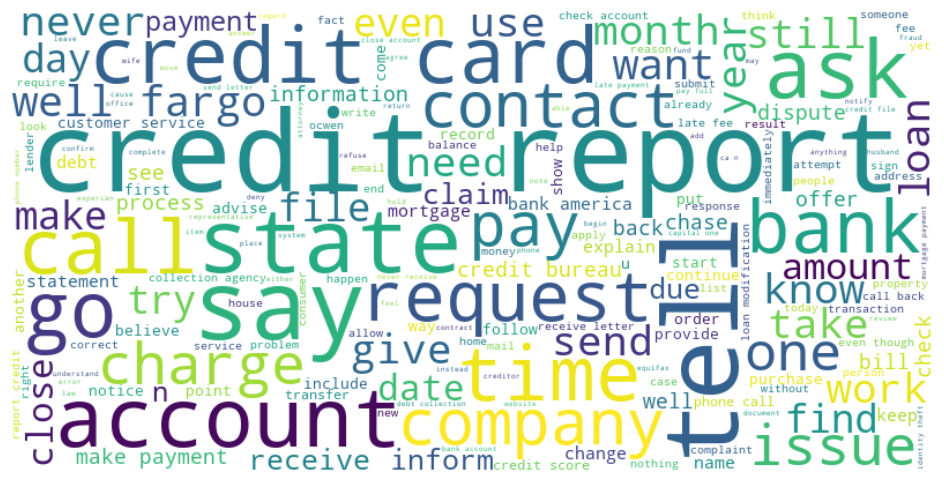

In [4]:
text_blob = " ".join(all_tokens)
wc = WordCloud(width=800, height=400, background_color="white").generate(text_blob)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

### 2.4 Wordclouds per product sector

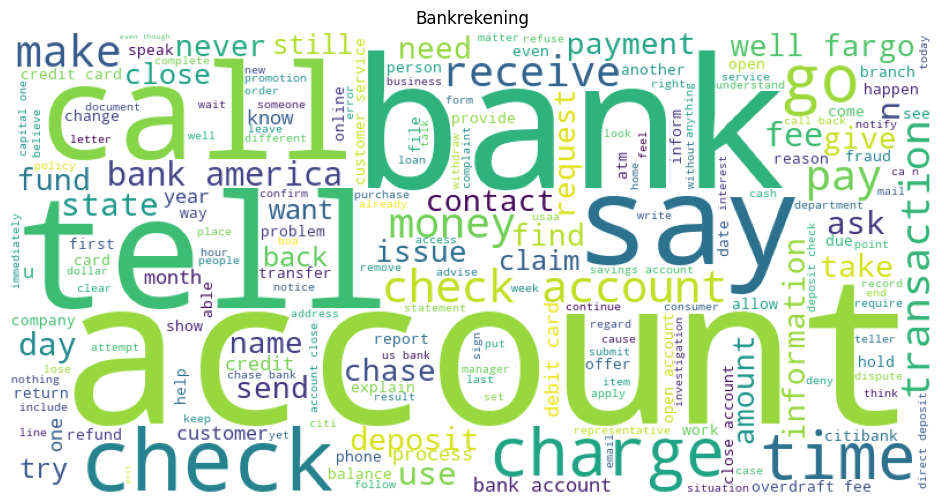

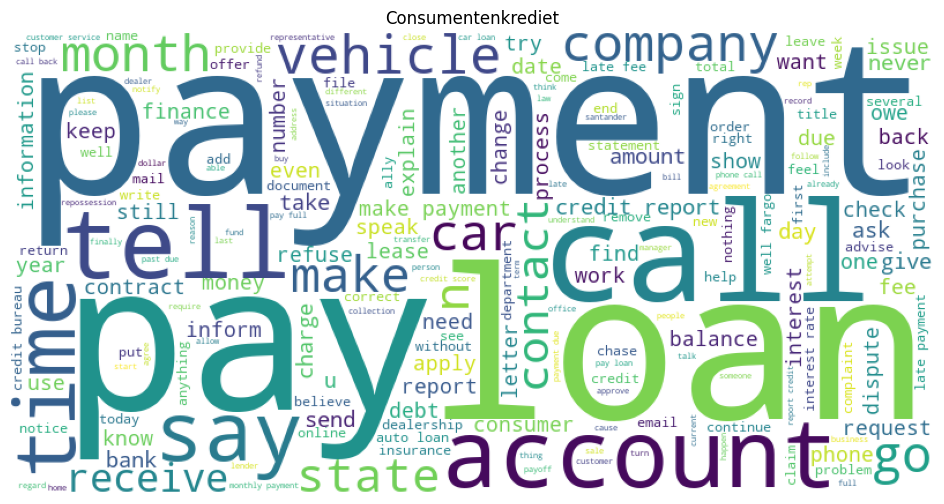

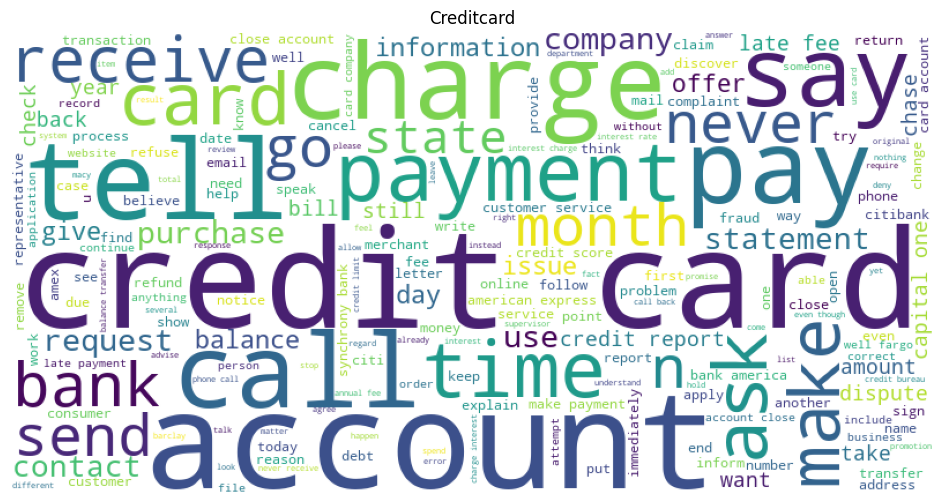

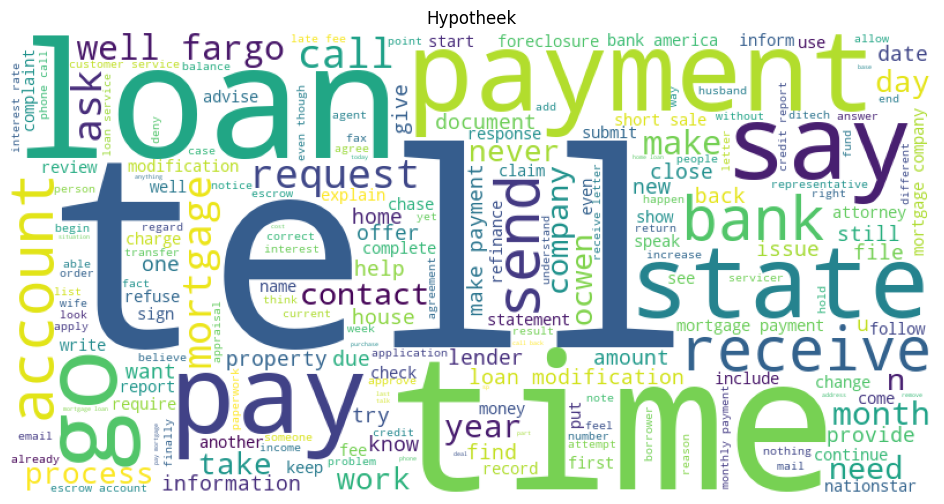

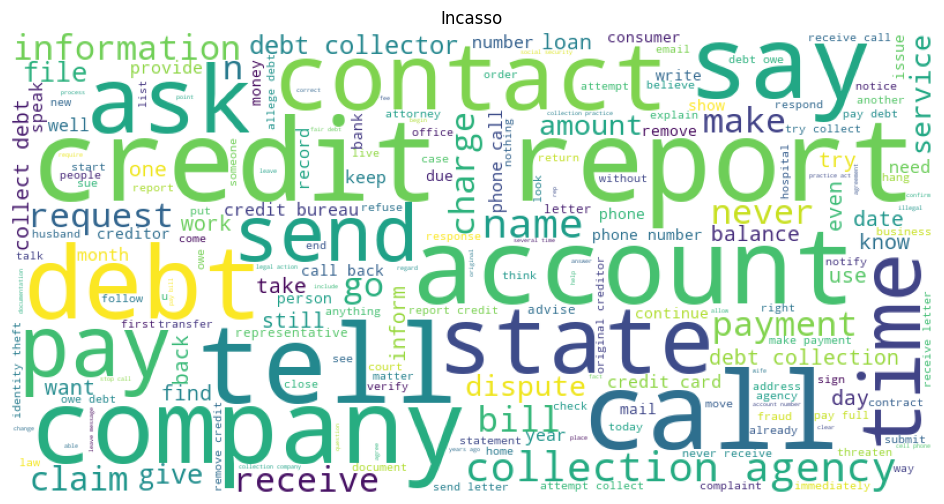

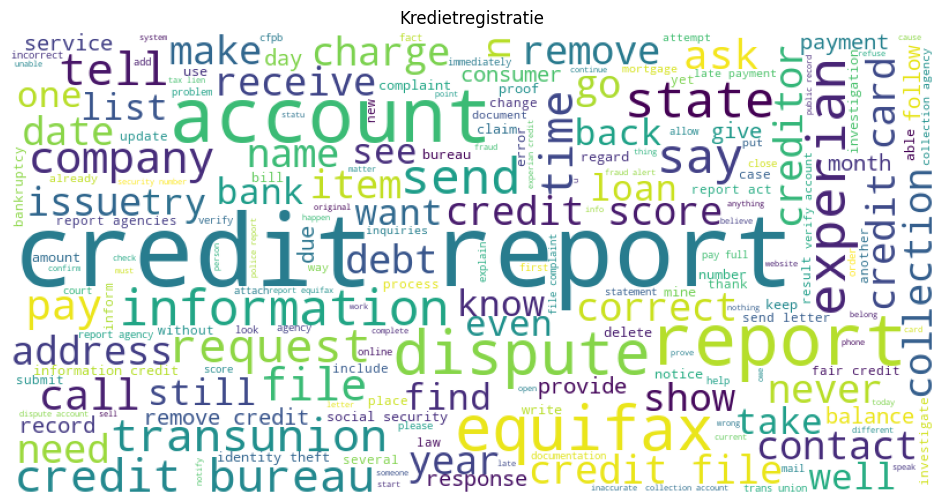

In [5]:
for product in df['Product'].unique():
    tokens = get_tokens_for_product(df, product)
    wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(tokens))
    plt.figure(figsize=(12,6))
    plt.imshow(wc)
    plt.title(product)
    plt.axis("off")
    plt.show()